# SHAP — interpretación del modelo ganador (Random Forest, ratio 1:1)

## Configuración
- **Dataset:** ratio **1:1**, reconstruido con la MISMA lógica de `tuning/v3` y del notebook
  de XGBoost (misma tabla base `pixel_year_full.csv`, buffer de exclusión de 3 km, semilla 42).
  Cambiar de ratio = una sola línea (`RATIO`).
- **Modelo:** Random Forest con los hiperparámetros de `tuning/v3` (se cargan del CSV si están;
  si no, fallback `n_estimators=500, max_features='sqrt', min_samples_leaf=5, max_depth=None`).
- **Explainer:** `shap.TreeExplainer` (exacto para árboles). Se explica la clase positiva (quemado).

### Nota de consistencia sobre el ratio
SHAP debe interpretar el MISMO modelo que genera el mapa. Si el mapa 2026 usa 2:1, cambia
`RATIO = 1` por `RATIO = 2`. La historia cualitativa es robusta al ratio; los valores absolutos no.

## Por qué SHAP y no la importancia por impureza
La impureza está sesgada hacia variables continuas con muchos cortes (NDVI, clima) y penaliza
distribuciones concentradas (distancias con muchos ceros) — por eso `dist_mosaic` quedó último
en impureza pese a tener la mayor discriminación bivariada. SHAP reparte la contribución de forma
justa por predicción, sin ese sesgo.

## Qué se espera
`dist_mosaic` debería **resurgir** en SHAP pese a que L1 lo eliminó y la impureza lo ranqueó
último → confirmaría que su efecto es no lineal (umbral), capturado por RF, cerrando el "por qué ML".

## Qué hace este notebook
1. Reconstruye el dataset 1:1. 2. Entrena el RF final. 3. Calcula SHAP (beeswarm, barra,
dependence plots). 4. Importancia por permutación (verificación convergente). 5. Guarda tabla
comparativa y figuras en `outputs/shap/`.

In [2]:
# === SHAP setup: dataset ratio 2:1 + Random Forest final (hiperparámetros de tuning/v3) ===

import os, glob, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap

def find_file(fname):
    for p in ([f'../../data/model_dataset/{fname}']
              + glob.glob(f'../../**/{fname}', recursive=True)
              + glob.glob(f'../../../**/{fname}', recursive=True)):
        if p and os.path.exists(p):
            return p
    raise FileNotFoundError(f"{fname} not found — check the repo path")

pixel_year = pd.read_csv(find_file('pixel_year_full.csv'))
pred_cols = ['dist_roads','dist_parks','dist_coca','dist_mosaic',
             'temp_C','vpd_kPa','ndvi','wind_ms','oni']
BLOCK = 0.25
EXCL_BUFFER = 3000
buffer_deg = EXCL_BUFFER / 111000
RATIO = 1                     # 1 = ratio 1:1. Switch to 2 for the 2:1 map model.
SEED = 42

presences = pixel_year[pixel_year['burned'] == 1].copy()
absences_all = pixel_year[pixel_year['burned'] == 0].copy()
kept = []
for y in sorted(pixel_year['year'].unique()):
    pres_y = presences[presences['year'] == y][['lon','lat']].values
    abs_y  = absences_all[absences_all['year'] == y]
    if len(pres_y) == 0:
        kept.append(abs_y); continue
    tree = cKDTree(pres_y)
    d, _ = tree.query(abs_y[['lon','lat']].values, k=1)
    kept.append(abs_y[d > buffer_deg])
absences_far = pd.concat(kept, ignore_index=True)
n_abs = min(len(absences_far), int(round(RATIO * len(presences))))
absences_sample = absences_far.sample(n=n_abs, random_state=SEED)
model_df = pd.concat([presences, absences_sample], ignore_index=True) \
             .sample(frac=1, random_state=SEED).reset_index(drop=True)
n_pres = int(model_df['burned'].sum())
print(f"Dataset ratio {RATIO}:1 ->", model_df.shape, f"({n_pres} presencias)")

RF_PARAMS = {'n_estimators':500, 'max_features':'sqrt', 'min_samples_leaf':5, 'max_depth':None}
try:
    v3 = pd.read_csv(find_file('tuning_v3_sensitivity_metrics.csv'))
    rf_row = v3[(v3['model'] == 'Random Forest') & (v3['n_rows'] == model_df.shape[0])]
    if len(rf_row) and 'best_params' in v3.columns and pd.notna(rf_row['best_params'].iloc[0]):
        RF_PARAMS = ast.literal_eval(rf_row['best_params'].iloc[0])
        print("Loaded RF best_params from tuning/v3:", RF_PARAMS)
    else:
        print("v3 best_params not found -> fallback:", RF_PARAMS)
except Exception as e:
    print("Could not read v3 params -> fallback:", RF_PARAMS, "|", type(e).__name__)

X_df = model_df[pred_cols].copy()
X = X_df.values
y = model_df['burned'].astype(int).values
rf = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1, **RF_PARAMS)
rf.fit(X, y)
print("Final RF trained on", X.shape[0], "rows.")

Dataset ratio 1:1 -> (4154, 13) (2077 presencias)
Loaded RF best_params from tuning/v3: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
Final RF trained on 4154 rows.


SHAP matrix shape: (4154, 9)


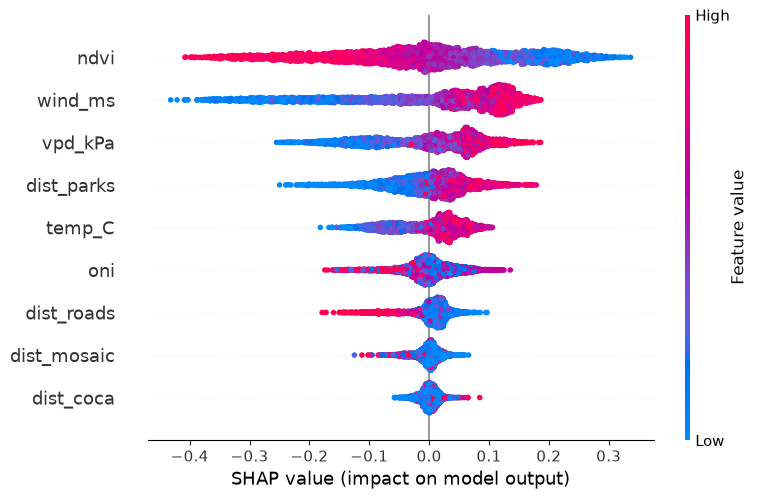

In [3]:
# === SHAP values + beeswarm summary ===
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X)
if isinstance(sv, list):
    shap_pos = sv[1]
elif getattr(sv, 'ndim', 2) == 3:
    shap_pos = sv[:, :, 1]
else:
    shap_pos = sv
print("SHAP matrix shape:", np.asarray(shap_pos).shape)

plt.figure()
shap.summary_plot(shap_pos, X_df, feature_names=pred_cols, show=False)
plt.tight_layout(); plt.savefig('shap_beeswarm.png', dpi=200, bbox_inches='tight'); plt.show()
# Read: right (positive SHAP) = pushes toward BURN. Colour = feature value (red high, blue low).
# For distances, low value = CLOSE.

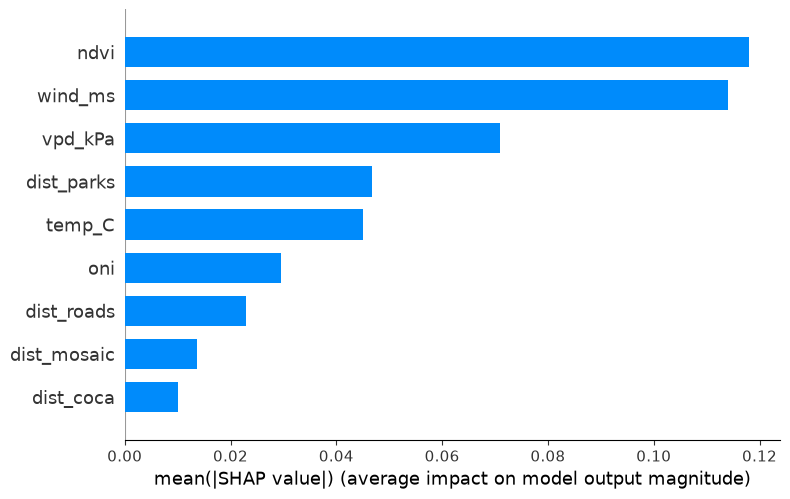

<Figure size 640x480 with 0 Axes>

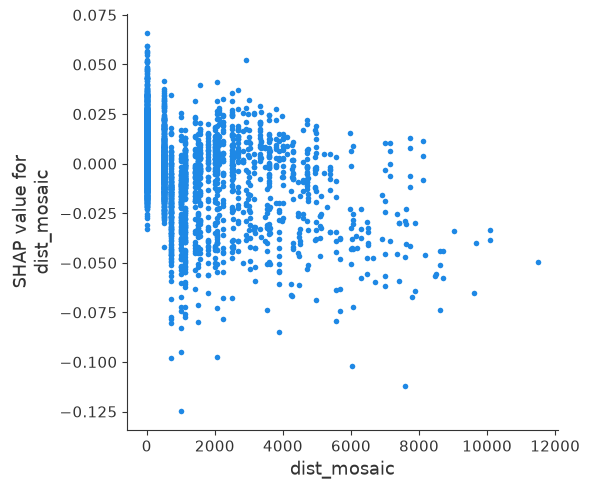

<Figure size 640x480 with 0 Axes>

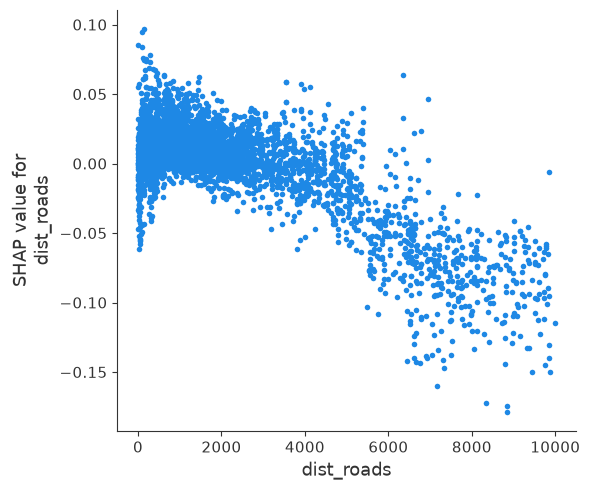

In [4]:
# === SHAP bar (mean |SHAP|) + dependence plots ===
plt.figure()
shap.summary_plot(shap_pos, X_df, feature_names=pred_cols, plot_type='bar', show=False)
plt.tight_layout(); plt.savefig('shap_bar.png', dpi=200, bbox_inches='tight'); plt.show()

for feat in ['dist_mosaic', 'dist_roads']:
    plt.figure()
    shap.dependence_plot(feat, shap_pos, X_df, interaction_index=None, show=False)
    plt.tight_layout(); plt.savefig(f'shap_dependence_{feat}.png', dpi=200, bbox_inches='tight'); plt.show()
# A steep drop near distance 0 that flattens = THRESHOLD effect (non-linear), unusable by a linear model.

In [5]:
# === Permutation importance + comparison of the 3 importance methods ===
perm = permutation_importance(rf, X, y, scoring='average_precision',
                              n_repeats=20, random_state=SEED, n_jobs=-1)
importance = pd.DataFrame({
    'predictor': pred_cols,
    'shap_mean_abs': np.abs(shap_pos).mean(axis=0),
    'impurity':      rf.feature_importances_,
    'permutation':   perm.importances_mean,
    'permutation_std': perm.importances_std,
})
for col in ['shap_mean_abs', 'impurity', 'permutation']:
    importance[f'rank_{col}'] = importance[col].rank(ascending=False).astype(int)
importance = importance.sort_values('shap_mean_abs', ascending=False).reset_index(drop=True)
print(importance.round(4).to_string(index=False))

  predictor  shap_mean_abs  impurity  permutation  permutation_std  rank_shap_mean_abs  rank_impurity  rank_permutation
       ndvi         0.1180    0.2147       0.1193           0.0048                   1              1                 1
    wind_ms         0.1141    0.2083       0.1046           0.0037                   2              2                 2
    vpd_kPa         0.0709    0.1463       0.0445           0.0019                   3              3                 3
 dist_parks         0.0467    0.0944       0.0386           0.0013                   4              5                 4
     temp_C         0.0451    0.1051       0.0226           0.0009                   5              4                 5
        oni         0.0294    0.0693       0.0209           0.0008                   6              7                 6
 dist_roads         0.0229    0.0732       0.0133           0.0007                   7              6                 7
dist_mosaic         0.0136    0.0374    

In [ ]:
# === Save outputs ===
importance.to_csv('shap_importance_comparison.csv', index=False)
print("Guardado: shap_importance_comparison.csv + figuras PNG")
mos = importance[importance['predictor'] == 'dist_mosaic'].iloc[0]
print(f"dist_mosaic -> SHAP #{mos['rank_shap_mean_abs']} | "
      f"impurity #{mos['rank_impurity']} | permutation #{mos['rank_permutation']}")

Guardado: shap_importance_comparison.csv + figuras PNG
dist_mosaic -> SHAP #8 | impurity #9 | permutation #8


: 